# Neural Network and Backpropagation


https://codewave.com/insights/development-of-neural-networks-history/

- A neural network is a machine-learning model designed to mimic the way the human brain processes information. 


## Perceptron

- Perceptron, Units or Nodes, are the simplest elements or building blocks in a neural network. 
- Inspired by biological neurons that are found in the human brain.



<div style="text-align: center;">

![Perceptron](perceptron.jpg)

</div>

by [Fotis Bobolas](https://commons.wikimedia.org/wiki/User:Bobolas)'s photo, licensed as CC BY-SA 2.0.


<div style="text-align: center;">

![hu](human.png)


</div>

### With single linear Perceptron
- A perceptron takes the inputs, $x_1, x_2, \ldots, x_n$, multiplies them by weights, $w_1, w_2, \ldots, w_n$ and adds the bias term, (constant term) $b$ or $w_0$, then computes the linear function --> Then output, $y = w_0 + w_1 x_1 + w_2 x_2 + \ldots + w_n x_n$. 
- Finally, if $y>0$, output 1, else output 0.

### Failure of single linear Perceptron: it can't solve XOR (Exclusive OR) and NAND (Not AND) problems.


> **Example: Marketing Campaign**
- Running marketing campaigns. 
- Two factors that might make people click:
    - Frequency: How often you contact them (0 = rarely/none, 1 = daily).
    - Urgency: How urgent your messages feel (0 = chill, 1 = big sale now!).
- Different combinations lead to clicks (1 = yes, they click) or no clicks (0 = no).

- OR: Click if at least one factor is strong.

| Frequency | Urgency | Strategy | Result (Click = 1) |
|-----------|---------|----------|--------------------|
| 0         | 0       | Silent   | 0 (nothing to click on) |
| 1         | 0       | Daily Friend | 1 (consistent engagement works) |
| 0         | 1       | Rare Big Sale | 1 (urgency drives action) |
| 1         | 1       | Frequent Urgent Promotions | 1 (either factor is enough to win) |

- AND: Click if both factors are strong.

| Frequency | Urgency | Strategy | Result (Click = 1) |
|-----------|---------|----------|--------------------|
| 0         | 0       | Silent   | 0 (no motivation at all) |
| 1         | 0       | Daily Friend (no urgency) | 0 (routine without excitement) |
| 0         | 1       | Rare Big Sale (one-time) | 0 (urgency alone isn't sustainable) |
| 1         | 1       | Consistent + High-Stakes Offers | 1 (both together create strong compulsion) |

- NAND: Click if both factors are **not** strong. 

| Frequency | Urgency | Strategy | Result (Click = 1) |
|-----------|---------|----------|--------------------|
| 0         | 0       | Silent   | 1 (curiosity or brand loyalty fills the void) |
| 1         | 0       | Daily Friend | 1 (steady touchpoints build trust) |
| 0         | 1       | Rare Big Sale | 1 (urgency alone grabs attention) |
| 1         | 1       | Spam / Overload | 0 (both together cause annoyance and opt-out) |

- XOR: Click only if exactly one factor is strong—either frequent but not urgent, or urgent but not frequent—but not both and not neither. Outputs true (1) only when the inputs are different — exactly one of them is true, but not both.


| $x_1$ | $x_2$ | Desired output                
|----|----|----------------
| 0  | 0  | 0              
| 1  | 0  | 1              
| 0  | 1  | 1              
| 1  | 1  | 0              

### Why a Linear Model (or Single Perceptron) Fails
- A linear model only learns:  $Result = w_1× x_1 (Frequency) + w_2× x_2 (Urgency) + b$

<div style="text-align: center;">

![XOR](XOR.png)

</div>

  
- **No single straight line** can separate the two classes.


***Mathematical Proof***

- **$Output = w_0 + w_1·x_1 + w_2·x_2$**

| $x_1$ | $x_2$ | Desired output | Required inequality                  
|----|----|----------------|--------------------------------------|
| 0  | 0  | 0              | $w_0$ ≤ 0                                → (1)
| 1  | 0  | 1              | $w_0 + w_1·x_1 + w_2·x_2 (=0)$ > 0       → (2)
| 0  | 1  | 1              | $w_0 + w_1·x_1 (=0) + w_2·x_2$ > 0       → (3)
| 1  | 1  | 0              | $w_0 + w_1·x_1 + w_2·x_2$ ≤ 0            → (4)

- Proof by contradiction

    - From (2): $w_1 + w_0 > 0$  →  $w_1 > –w_0$  
    - From (3):  $w_2 + w_0 > 0$ →  $w_2 > –w_0$
    - Add these two inequalities:  $w_1 + w_2 > –2w_0$  
    - Now plug into (4): $w_1 + w_2 + w_0 > –2w_0 + w_0 = –w_0$ 
    - But from (1) we know $w_0 \leq 0$, so $–w_0 > 0$.  
    - Therefore: $w_1 + w_2 + w_0 > -w_0 > 0$  → $w_1 + w_2 + w_0 > 0$
    - This **directly contradicts** requirement (4): $w_1 + w_2 + w_0 \leq 0$.

**Conclusion**: 
- It is **mathematically impossible** to satisfy all four inequalities at once.  
- At least one point will always be misclassified.
- And why we needed **multi-layer neural networks** with non-linear activation functions to solve problems like XOR.

https://codewave.com/insights/development-of-neural-networks-history/

***Deep Learning or Neural Networksis with non-linear activation functions is in power.***


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
sns.set_style("whitegrid")

mpl.rcParams['figure.figsize'] = (12, 6) 
mpl.rcParams['axes.grid'] = True

import warnings
warnings.filterwarnings("ignore")

In [5]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])

y_and  = np.array([0, 0, 0, 1])
y_or   = np.array([0, 1, 1, 1])
y_xor  = np.array([0, 1, 1, 0])
y_nand = np.array([1, 1, 1, 0])

### Perceptron: for binary classification

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html


In [2]:
from sklearn.linear_model import Perceptron


In [ ]:
model = Perceptron()
# model.fit(X, y_and)
# model.fit(X, y_or)
model.fit(X, y_xor)

# print(model.score(X, y_and))
# print(model.score(X, y_or))
print(model.score(X, y_xor))

0.5


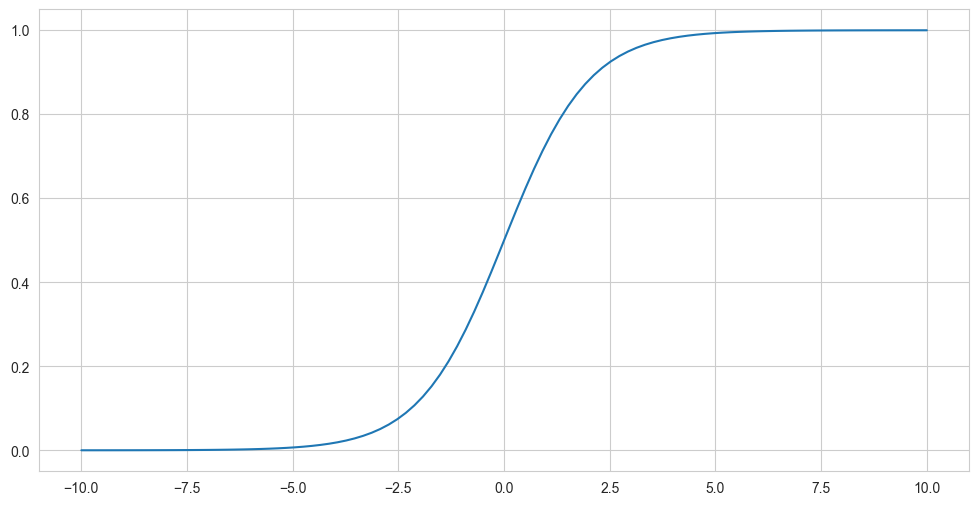

In [8]:
x = np.linspace(-10, 10, 100)
sigmoid = lambda z: 1 / (1 + np.exp(-z))
plt.plot(x, sigmoid(x));

## How to add non-linearity to Perceptron

- Add non-linearity to Perceptron using Activation Function (example: Sigmoid Function)
$$y = \frac{1}{1 + e^{-(w_0 + w_1x_1 + w_2x_2 + ... + w_nx_n)}}$$


- With 1 dimension

$$
y = \frac{1}{1 + e^{-(w_0 + w_1x)}}
$$

- With 2 Dimensions***

$$
y = \frac{1}{1 + e^{-(w_0 + w_1x_1 + w_2x_2)}}
$$

## Sigmoid Function Review

The sigmoid function is a mathematical function that maps any real number to a value between 0 and 1:

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

Key Properties

- **Range**: (0, 1)
    - Output is always between 0 and 1

- **S-shaped Curve**
    - Smooth, continuous, and differentiable
    - Monotonically increasing

Why Use Sigmoid in Neural Networks?

- **Non-linearity**: Introduces non-linear transformations
- **Bounded output**: Prevents exploding gradients
- **Smooth gradient**: Enables gradient-based optimization
- **Output can be interpreted as probability**
    - Values > 0.5 → Class 1, Values < 0.5 → Class 0
    - Mimics neuron firing behavior
    - "All-or-nothing" response with smooth transition

- **Mathematical Advantages (Derivative):** $\sigma'(x) = \sigma(x)(1 - \sigma(x))$
    - Derivative expressed in terms of function itself
    - No need to recompute exponentials during backpropagation

Modern Alternatives

- **Tanh**: $f(x) = \tanh(x)$ 
- **ReLU**: $f(x) = \max(0, x)$


## My First Neural Network

### Neural Network is to find (learn) the best weights:
$$
w^* = \underset{w}{\operatorname{argmin}} \sum_{i=1}^N \mathcal{L}(y_i, f(x_i; w))
$$

- 2-input, 1-hidden layer with 2 nodes, 1-output neural network:
    - **Inputs**: $x_1, x_2$
    - **Hidden layer** with two nodes, $z_{h1}, z_{h2}$ with sigmoid activation
    - **Output**: $y$ with sigmoid activation



![Neural Network](nn.png)



 Step | Calculation | Saved value |
|------|------|-------------|
| pre-h1 | z_h1 = x1(=0.5)·w11(=0.2) + x2(=0.8)·w21(=0.4) + b_h1(=0) | z_h1 |
| act-h1 | a_h1 = σ(z_h1) | a_h1 |
| pre-h2 | z_h2 = x1·w12(=0.3) + x2·w22(=0.5) + b_h2(=0) | z_h2 |
| act-h2 | a_h2 = σ(z_h2) | a_h2 |
| pre-o  | z_o  = a_h1·w1o(=0.1) + a_h2·w2o(=0.6) + b_o(=0) | z_o |
| output | y_pred = σ(z_o) | y_pred |



- Actually, this is same as equation as following:

$$
y = \frac{1}{
1 + \exp\Biggl( 
    -\left[ 
        z_{o1} + 
        z_{11}\left(\frac{1}{1 + e^{-(w_{01} + w_{11}x_1 + w_{21}x_2)}}\right) + 
        z_{21}\left(\frac{1}{1 + e^{-(w_{02} + w_{12}x_1 + w_{22}x_2)}}\right)
    \right]
\Biggr)
}
$$

or

$$
y = \sigma\!\Bigl(
    z_{o1} + z_{11}\,\sigma(w_{01} + w_{11}x_1 + w_{21}x_2) + z_{21}\,\sigma(w_{02} + w_{12}x_1 + w_{22}x_2)
\Bigr)
$$



## Forward Pass Equations
$$
\begin{align*}
z_{h1} &= x_1 w_{11} + x_2 w_{21} + b_{h1} \\
a_{h1} &= \sigma(z_{h1}) \\
z_{h2} &= x_1 w_{12} + x_2 w_{22} + b_{h2} \\
a_{h2} &= \sigma(z_{h2}) \\
z_o &= a_{h1} w_{1o} + a_{h2} w_{2o} + b_o \\
y_{pred} &= \sigma(z_o)
\end{align*}
$$

#### 1. Calculate Hidden Layer Node h₁:
- h₁_input = (x₁ ⋅ w₁₁) + (x₂ ⋅ w₂₁) + b_h₁ --> (0.5 ⋅ 0.2) + (0.8 ⋅ 0.4) + 0.0 = 0.1 + 0.32 = 0.42
- a_h1 = 1 / (1 + e^(-0.42)) 


In [17]:
x1 = 0.5
x2 = 0.8

y_target = 1.0


# wegiths
w11 = 0.2
w21 = 0.4

w12 = 0.3
w22 = 0.5

w1o = 0.1
w2o = 0.6

b_h1, b_h2, b_o1 = 0.0, 0.0, 0.0

In [ ]:
# h1
h1 = b_h1 + w11*x1 + w21*x2
z_h1 = sigmoid(h1)

In [14]:
z_h1

np.float64(0.6034832498647263)

In [15]:
h2 = b_h2 + w12*x1 + w22*x2
z_h2 = sigmoid(h2)

In [16]:
z_h2

np.float64(0.6341355910108007)

#### 3. Calculate Output Layer Node o₁:
o₁_input = (a_h1 ⋅ w₁o) + (a_h2 ⋅ w₂o) + b_o₁


In [19]:
oo = b_o1 + w1o * z_h1 + w2o * z_h2
y_pred = sigmoid(oo)

In [20]:
y_pred

np.float64(0.6084567090183433)

**Hidden Layer Outputs:**
- h₁_output = sigmoid(0.42) = 1/(1 + e⁻⁰·⁴²) ≈ 0.603
- h₂_output = sigmoid(0.55) = 1/(1 + e⁻⁰·⁵⁵) ≈ 0.634

**Final Output:**
- o₁_input = (0.603 ⋅ 0.1) + (0.634 ⋅ 0.6) + 0.0 = 0.0603 + 0.3804 = 0.4407
- o₁_output = sigmoid(0.4407) = 1/(1 + e⁻⁰·⁴⁴⁰⁷) ≈ 0.608

The network predicts **0.608** compared to the target **1.0**.

In [23]:
# Error: MSE
error = y_target - y_pred
mse = (error)**2
mse


np.float64(0.1533061487127463)

## Backpropagation 
- With calculated error, compute gradients using chain rule 
- Update weights in the direction that reduces error (Gradient Descent Algorithm)

- Cost Function (MSE)
$$C = \frac{1}{2N}\sum_{i=1}^{N}(y_{target} - y_{pred})^2$$


### Backpropagation: Computing Gradients for Single Sample

- **Step 1: Output Layer Gradients**

    - **Gradient w.r.t. output weights ($w_{1o}, w_{2o}$):**
        - Using chain rule: $$\frac{\partial C}{\partial w_{1o}} = \frac{\partial C}{\partial y_{pred}} \cdot \frac{\partial y_{pred}}{\partial z_o} \cdot \frac{\partial z_o}{\partial w_{1o}}$$
        - **Component 1:** $\frac{\partial C}{\partial y_{pred}} = -(y_{target} - y_{pred})$
        - **Component 2:** $\frac{\partial y_{pred}}{\partial z_o} = y_{pred}(1 - y_{pred})$ from sigmoid derivative
        - **Component 3:** $\frac{\partial z_o}{\partial w_{1o}} = a_{h1}$
        - **Final result:** $\frac{\partial C}{\partial w_{1o}} = -(y_{target} - y_{pred}) \cdot y_{pred}(1 - y_{pred}) \cdot a_{h1}$

    - Similarly: $\frac{\partial C}{\partial w_{2o}} = -(y_{target} - y_{pred}) \cdot y_{pred}(1 - y_{pred}) \cdot a_{h2}$
    - Define output error term as $\delta_o = -(y_{target} - y_{pred}) \cdot y_{pred}(1 - y_{pred})$ 
    
    - Finally, $\frac{\partial C}{\partial w_{1o}} = \delta_o \cdot a_{h1}$ and $\frac{\partial C}{\partial w_{2o}} = \delta_o \cdot a_{h2}$



In [28]:
delta_o = -(y_target - y_pred)*y_pred*(1-y_pred)
delta_o
cw1o = delta_o* z_h1
cw2o = delta_o* z_h2

In [29]:
cw1o, cw2o

(np.float64(-0.05629301091712386), np.float64(-0.05915226604169965))

- **Step 2: Hidden Layer Gradients**

    - **Gradient w.r.t. hidden weights ( $w_{11}, w_{21}, w_{12}, w_{22}$ ):**

    - For $w_{11}$: $\frac{\partial C}{\partial w_{11}} = \frac{\partial C}{\partial y_{pred}} \cdot \frac{\partial y_{pred}}{\partial z_o} \cdot \frac{\partial z_o}{\partial a_{h1}} \cdot \frac{\partial a_{h1}}{\partial z_{h1}} \cdot \frac{\partial z_{h1}}{\partial w_{11}}$

        - **Component 1 & 2:** Already computed as $\delta_o$
        - **Component 3:** $\frac{\partial z_o}{\partial a_{h1}} = w_{1o}$
        - **Component 4:** $\frac{\partial a_{h1}}{\partial z_{h1}} = a_{h1}(1 - a_{h1})$ (sigmoid derivative)
        - **Component 5:** $\frac{\partial z_{h1}}{\partial w_{11}} = x_1$

    - **Final result:** $\frac{\partial C}{\partial w_{11}} = \delta_o \cdot w_{1o} \cdot a_{h1}(1 - a_{h1}) \cdot x_1$
    - **Let's define following hidden error terms as: $\delta_{h1} = \delta_o \cdot w_{1o} \cdot a_{h1}(1 - a_{h1})$ and $\delta_{h2} = \delta_o \cdot w_{2o} \cdot a_{h2}(1 - a_{h2})$

- All hidden layer gradients:   
$$\frac{\partial C}{\partial w_{11}} = \delta_{h1} \cdot x_1$$
$$\frac{\partial C}{\partial w_{21}} = \delta_{h1} \cdot x_2$$
$$\frac{\partial C}{\partial w_{12}} = \delta_{h2} \cdot x_1$$
$$\frac{\partial C}{\partial w_{22}} = \delta_{h2} \cdot x_2$$



In [32]:
c_w11 = delta_o*w1o*z_h1*(1-z_h1)*x1
c_w12 = delta_o*w1o*z_h1*(1-z_h1)*x2

c_w21 = delta_o*w2o*z_h2*(1-z_h2)*x1
c_w22 = delta_o*w2o*z_h2*(1-z_h2)*x2

In [33]:
c_w11, c_w12, c_w21, c_w22

(np.float64(-0.0011160560872093717),
 np.float64(-0.001785689739534995),
 np.float64(-0.006492512656715496),
 np.float64(-0.010388020250744794))

### Backpropagation Algorithm Summary

#### **Forward Pass:**
1. Compute activations layer by layer
2. Calculate final prediction and cost

#### **Backward Pass:**
-**Weight Updates:**
$$w_{new} = w_{old} - \alpha \cdot \frac{\partial C}{\partial w}$$

where $\alpha$ is the learning rate.


In [35]:
learning_rate = 0.1

w1o_new = w1o - learning_rate * cw1o
w2o_new = w2o - learning_rate * cw2o

# cw1o, cw2o
w11_new = w11 - learning_rate * c_w11
w12_new = w12 - learning_rate * c_w12

w21_new = w21 - learning_rate * c_w21
w22_new = w22 - learning_rate * c_w22

In [36]:
w1o_new, w2o_new, w11_new, w12_new, w21_new, w22_new

(np.float64(0.1056293010917124),
 np.float64(0.60591522660417),
 np.float64(0.20011160560872096),
 np.float64(0.3001785689739535),
 np.float64(0.4006492512656716),
 np.float64(0.5010388020250744))

- Using new weights, do forward propagation
- Calculate the error
- Using backpropagation, calculate the gradient
- Update the weights
- repeat until convergence